In [ ]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix, hstack, eye
from lightfm import LightFM
from lightfm.evaluation import precision_at_k as lfm_precision_at_k
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
np.random.seed(42)

In [2]:
df = pd.read_csv('../../data/children_products/clildren_product_cleaned.csv', low_memory=False)
print(f"Исходный датасет: {df.shape}")

df_filtered = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
df_filtered = df_filtered.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df_filtered['Дата'] = pd.to_datetime(df_filtered['Дата'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Дата'])

# Конвертация числовых колонок
for col in ['Цена']:
    if col in df_filtered.columns:
        df_filtered[col] = df_filtered[col].astype(str).str.replace(' ', '').str.replace(',', '.')
        df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

MIN_INTERACTIONS = 5
for _ in range(5):
    user_counts = df_filtered.groupby('Телефон_new').size()
    item_counts = df_filtered.groupby('ID_SKU').size()
    active_users = user_counts[user_counts >= MIN_INTERACTIONS].index
    active_items = item_counts[item_counts >= MIN_INTERACTIONS].index
    before = len(df_filtered)
    df_filtered = df_filtered[
        df_filtered['Телефон_new'].isin(active_users) &
        df_filtered['ID_SKU'].isin(active_items)
    ]
    if len(df_filtered) == before:
        break

print(f"Пользователей: {df_filtered['Телефон_new'].nunique():,}")
print(f"Товаров:       {df_filtered['ID_SKU'].nunique():,}")
print(f"Взаимодействий:{len(df_filtered):,}")
print(f"Колонки: {list(df_filtered.columns)}")

Исходный датасет: (610913, 16)
Пользователей: 17,442
Товаров:       8,488
Взаимодействий:227,170
Колонки: ['Дата', 'НомерЗаказаНаСайте', 'МетодДоставки', 'Группа2', 'Группа3', 'Тип', 'Отменено', 'Количество', 'Цена', 'Статус', 'Гео', 'Маржа', 'СуммаУслуг', 'Телефон_new', 'ID_SKU', 'МетодДоставки_Групп']


In [3]:
interactions = (
    df_filtered
    .groupby(['Телефон_new', 'ID_SKU'])
    .agg(last_date=('Дата', 'max'), count=('Дата', 'count'))
    .reset_index()
)

users = interactions['Телефон_new'].unique()
items = interactions['ID_SKU'].unique()
user2id = {u: i for i, u in enumerate(users)}
item2id = {it: i for i, it in enumerate(items)}

interactions['user_id'] = interactions['Телефон_new'].map(user2id)
interactions['item_id'] = interactions['ID_SKU'].map(item2id)

n_users = len(users)
n_items = len(items)

interactions = interactions.sort_values('last_date')
split_ts = interactions['last_date'].quantile(0.8)
print(f"Дата разделения: {split_ts}")

train_df = interactions[interactions['last_date'] <  split_ts]
test_df  = interactions[interactions['last_date'] >= split_ts]

train_users = set(train_df['user_id'].unique())
test_df = test_df[test_df['user_id'].isin(train_users)]

# Присоединяем оригинальные транзакции для агрегации фичей
interactions_merged = df_filtered.merge(
    interactions[['Телефон_new', 'ID_SKU', 'user_id', 'item_id', 'last_date']],
    on=['Телефон_new', 'ID_SKU']
)
train_raw = interactions_merged[interactions_merged['Дата'] < split_ts]

print(f"Train: {len(train_df):,} пар, {train_df['user_id'].nunique():,} users")
print(f"Test:  {len(test_df):,} пар,  {test_df['user_id'].nunique():,} users")

Дата разделения: 2017-04-18 23:48:00
Train: 162,552 пар, 15,609 users
Test:  24,193 пар,  3,824 users


In [4]:
def build_sparse(df, n_users, n_items):
    return csr_matrix(
        (np.ones(len(df)), (df['user_id'].values, df['item_id'].values)),
        shape=(n_users, n_items)
    )

train_matrix = build_sparse(train_df, n_users, n_items)
test_matrix  = build_sparse(test_df,  n_users, n_items)

print(f"Train matrix: {train_matrix.shape}, ненулевых: {train_matrix.nnz:,}")
print(f"Test matrix:  {test_matrix.shape},  ненулевых: {test_matrix.nnz:,}")

Train matrix: (17442, 8488), ненулевых: 162,552
Test matrix:  (17442, 8488),  ненулевых: 24,193


In [5]:
user_agg = train_raw.groupby('Телефон_new').agg(
    geo_mode=('Гео', lambda x: x.mode().iloc[0] if len(x) > 0 else 'Регионы'),
    delivery_mode=('МетодДоставки', lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown'),
    avg_price=('Цена', 'mean'),
    n_orders=('НомерЗаказаНаСайте', 'nunique'),
).reset_index()

user_agg['user_id'] = user_agg['Телефон_new'].map(user2id)
user_agg = user_agg.dropna(subset=['user_id'])
user_agg['user_id'] = user_agg['user_id'].astype(int)

user_agg['price_bin'] = pd.qcut(
    user_agg['avg_price'], q=3, labels=['price_low', 'price_mid', 'price_high'], duplicates='drop'
)
user_agg['orders_bin'] = pd.qcut(
    user_agg['n_orders'].rank(method='first'), q=3,
    labels=['orders_low', 'orders_mid', 'orders_high']
)

def group_delivery(method):
    method = str(method)
    if 'Курьерская' in method: return 'delivery_courier'
    elif 'Магазины' in method or 'Самовывоз' in method: return 'delivery_store'
    else: return 'delivery_pickup'

user_agg['delivery_group'] = user_agg['delivery_mode'].apply(group_delivery)
user_agg['geo_feature'] = 'geo_' + user_agg['Гео'].astype(str) if 'Гео' in user_agg.columns else 'geo_' + user_agg['geo_mode'].astype(str)

# Корректируем имя колонки
if 'geo_feature' not in user_agg.columns or user_agg['geo_feature'].str.startswith('geo_nan').any():
    user_agg['geo_feature'] = 'geo_' + user_agg['geo_mode'].astype(str)

print(f"Пользователей с фичами: {len(user_agg):,}")
print("\nГео:", user_agg['geo_feature'].value_counts().to_dict())
print("Доставка:", user_agg['delivery_group'].value_counts().to_dict())

Пользователей с фичами: 15,710

Гео: {'geo_Москва': 8374, 'geo_Регионы': 5417, 'geo_МО': 1919}
Доставка: {'delivery_store': 9466, 'delivery_courier': 5524, 'delivery_pickup': 720}


In [6]:
user_feature_list = []
for _, row in user_agg.iterrows():
    features = [
        row['geo_feature'],
        row['delivery_group'],
        str(row['price_bin']),
        str(row['orders_bin']),
    ]
    user_feature_list.append((int(row['user_id']), features))

all_user_features = sorted(set(f for _, feats in user_feature_list for f in feats))
print(f"Уникальных user-фичей: {len(all_user_features)}")
print(all_user_features)

Уникальных user-фичей: 12
['delivery_courier', 'delivery_pickup', 'delivery_store', 'geo_МО', 'geo_Москва', 'geo_Регионы', 'orders_high', 'orders_low', 'orders_mid', 'price_high', 'price_low', 'price_mid']


In [7]:
item_agg = train_raw.groupby('ID_SKU').agg(
    group2_mode=('Группа2', lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown'),
    group3_mode=('Группа3', lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown'),
    type_mode=('Тип', lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown'),
    avg_price=('Цена', 'mean'),
).reset_index()

item_agg['item_id'] = item_agg['ID_SKU'].map(item2id)
item_agg = item_agg.dropna(subset=['item_id'])
item_agg['item_id'] = item_agg['item_id'].astype(int)

item_agg['item_price_bin'] = pd.qcut(
    item_agg['avg_price'], q=4,
    labels=['item_cheap', 'item_budget', 'item_mid', 'item_premium'],
    duplicates='drop'
)

item_agg['group2_feat'] = 'g2_' + item_agg['group2_mode'].astype(str)
item_agg['group3_feat'] = 'g3_' + item_agg['group3_mode'].astype(str)
item_agg['type_feat']   = 'type_' + item_agg['type_mode'].astype(str)

print(f"Товаров с фичами: {len(item_agg):,}")
print(f"Группа2: {item_agg['group2_feat'].nunique()}, Группа3: {item_agg['group3_feat'].nunique()}, Тип: {item_agg['type_feat'].nunique()}")

Товаров с фичами: 8,412
Группа2: 13, Группа3: 71, Тип: 5


In [8]:
item_feature_list = []
for _, row in item_agg.iterrows():
    features = [
        row['group2_feat'],
        row['group3_feat'],
        row['type_feat'],
        str(row['item_price_bin']),
    ]
    item_feature_list.append((int(row['item_id']), features))

all_item_features = sorted(set(f for _, feats in item_feature_list for f in feats))
print(f"Уникальных item-фичей: {len(all_item_features)}")

Уникальных item-фичей: 93


In [9]:
def build_feature_matrix(feature_list, all_features, n_entities):
    feat_to_idx = {f: i for i, f in enumerate(all_features)}
    rows, cols, data = [], [], []
    for entity_id, feats in feature_list:
        for f in feats:
            if f in feat_to_idx:
                rows.append(entity_id)
                cols.append(feat_to_idx[f])
                data.append(1.0)
    side_matrix = csr_matrix(
        (data, (rows, cols)),
        shape=(n_entities, len(all_features))
    )
    return hstack([eye(n_entities, format='csr'), side_matrix], format='csr')


user_features_matrix = build_feature_matrix(user_feature_list, all_user_features, n_users)
item_features_matrix = build_feature_matrix(item_feature_list, all_item_features, n_items)

print(f"User features: {user_features_matrix.shape}  ({n_users} users + {len(all_user_features)} features)")
print(f"Item features: {item_features_matrix.shape}  ({n_items} items + {len(all_item_features)} features)")

User features: (17442, 17454)  (17442 users + 12 features)
Item features: (8488, 8581)  (8488 items + 93 features)


In [11]:
model = LightFM(
    no_components=64,
    loss='warp',
    learning_rate=0.05,
    item_alpha=1e-6,
    user_alpha=1e-6,
    random_state=42
)

NUM_EPOCHS = 20
NUM_THREADS = 16  # без OpenMP

train_precisions = []
for epoch in range(NUM_EPOCHS):
    model.fit_partial(
        train_matrix,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        epochs=1,
        num_threads=NUM_THREADS
    )
    if (epoch + 1) % 5 == 0:
        p = lfm_precision_at_k(
            model, train_matrix,
            user_features=user_features_matrix,
            item_features=item_features_matrix,
            k=10, num_threads=NUM_THREADS
        ).mean()
        train_precisions.append((epoch + 1, p))
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}: train Precision@10 = {p:.4f}")

print("Обучение завершено")

Epoch 5/20: train Precision@10 = 0.1035
Epoch 10/20: train Precision@10 = 0.1305
Epoch 15/20: train Precision@10 = 0.1500
Epoch 20/20: train Precision@10 = 0.1682
Обучение завершено


In [12]:
def precision_at_k(rec, rel, k):
    return len(set(rec[:k]) & set(rel)) / k if rec else 0.0

def recall_at_k(rec, rel, k):
    return len(set(rec[:k]) & set(rel)) / len(rel) if rel else 0.0

def map_at_k(rec, rel, k):
    rel_set = set(rel)
    if not rel_set: return 0.0
    score, hits = 0.0, 0.0
    for i, item in enumerate(rec[:k]):
        if item in rel_set:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(rel_set), k)

def ndcg_at_k(rec, rel, k):
    rel_set = set(rel)
    if not rel_set: return 0.0
    dcg  = sum(1.0 / np.log2(i + 2) for i, item in enumerate(rec[:k]) if item in rel_set)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(rel_set), k)))
    return dcg / idcg if idcg > 0 else 0.0


test_user_items = test_df.groupby('user_id')['item_id'].apply(list).to_dict()
eval_users = list(test_user_items.keys())
all_items = np.arange(n_items)
print(f"Оценка на {len(eval_users):,} пользователях...")

K_VALUES = [5, 10, 20]
metrics = {k: {'precision': [], 'recall': [], 'map': [], 'ndcg': []} for k in K_VALUES}

for user_id in eval_users:
    scores = model.predict(
        user_id, all_items,
        user_features=user_features_matrix,
        item_features=item_features_matrix
    )
    bought = set(train_matrix[user_id].indices)
    rec = [i for i in np.argsort(-scores) if i not in bought]
    rel = test_user_items[user_id]
    for k in K_VALUES:
        metrics[k]['precision'].append(precision_at_k(rec, rel, k))
        metrics[k]['recall'].append(recall_at_k(rec, rel, k))
        metrics[k]['map'].append(map_at_k(rec, rel, k))
        metrics[k]['ndcg'].append(ndcg_at_k(rec, rel, k))

results = {k: {m: float(np.mean(v)) for m, v in mv.items()} for k, mv in metrics.items()}
print("Готово")

Оценка на 3,824 пользователях...
Готово


In [13]:
print("=== LightFM WARP + Features ===")
for k in K_VALUES:
    r = results[k]
    print(f"\nK={k}:")
    print(f"  Precision@{k}: {r['precision']:.4f}")
    print(f"  Recall@{k}:    {r['recall']:.4f}")
    print(f"  MAP@{k}:       {r['map']:.4f}")
    print(f"  NDCG@{k}:      {r['ndcg']:.4f}")

=== LightFM WARP + Features ===

K=5:
  Precision@5: 0.0312
  Recall@5:    0.0306
  MAP@5:       0.0234
  NDCG@5:      0.0384

K=10:
  Precision@10: 0.0282
  Recall@10:    0.0529
  MAP@10:       0.0234
  NDCG@10:      0.0449

K=20:
  Precision@20: 0.0240
  Recall@20:    0.0854
  MAP@20:       0.0253
  NDCG@20:      0.0557


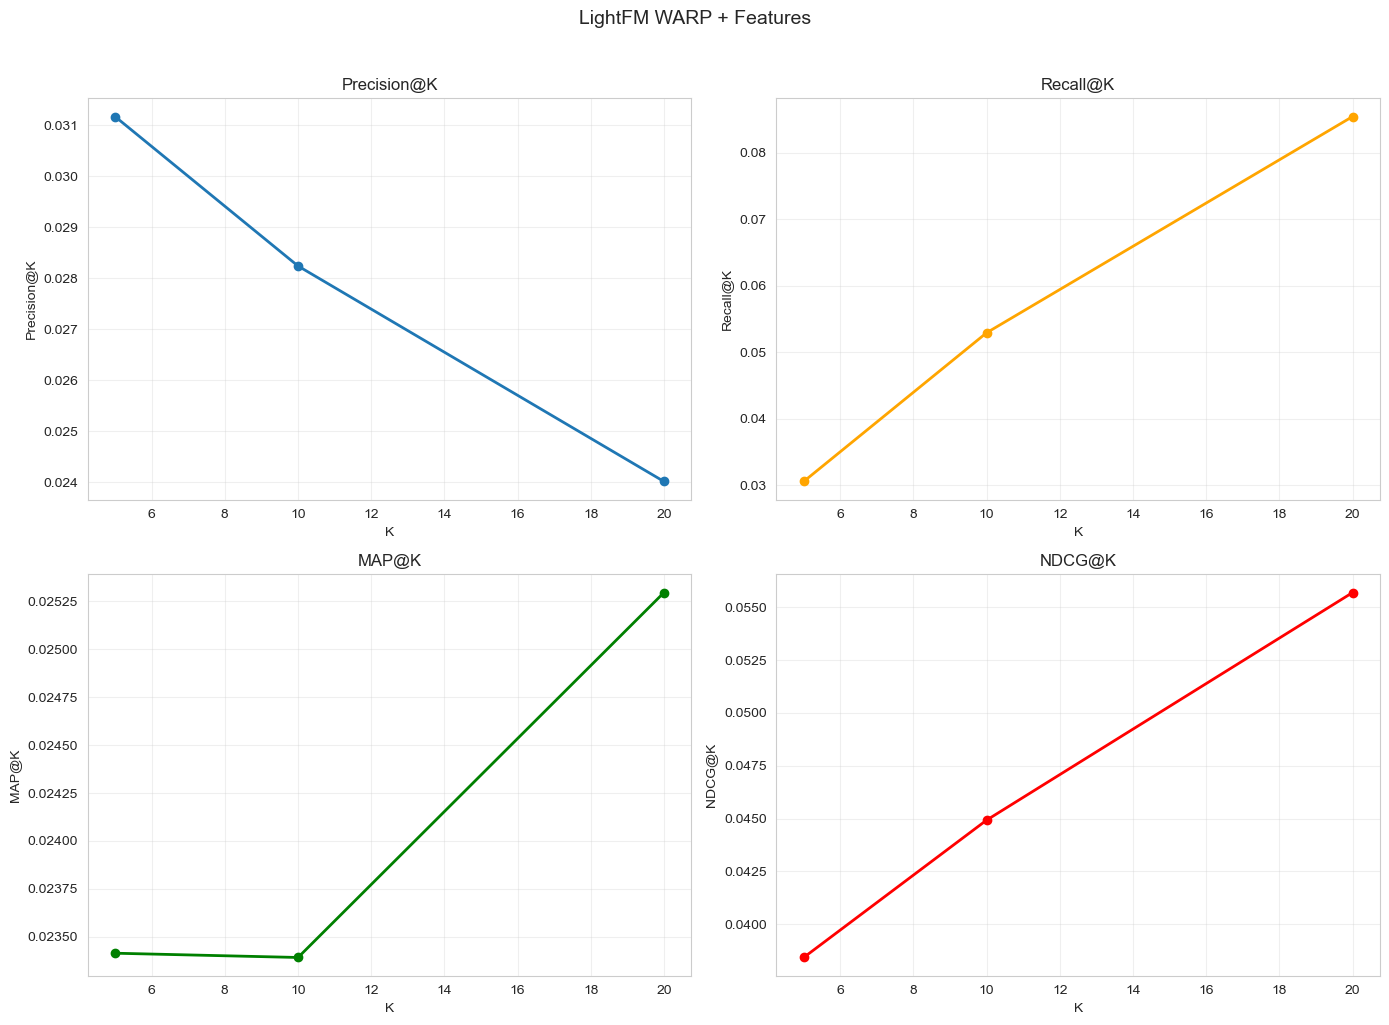

In [14]:
metrics_df = pd.DataFrame(results).T
metrics_df.index.name = 'K'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(metrics_df.index, metrics_df['precision'], marker='o', linewidth=2)
axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Precision@K')
axes[0, 0].set_title('Precision@K'); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(metrics_df.index, metrics_df['recall'], marker='o', linewidth=2, color='orange')
axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Recall@K')
axes[0, 1].set_title('Recall@K'); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(metrics_df.index, metrics_df['map'], marker='o', linewidth=2, color='green')
axes[1, 0].set_xlabel('K'); axes[1, 0].set_ylabel('MAP@K')
axes[1, 0].set_title('MAP@K'); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(metrics_df.index, metrics_df['ndcg'], marker='o', linewidth=2, color='red')
axes[1, 1].set_xlabel('K'); axes[1, 1].set_ylabel('NDCG@K')
axes[1, 1].set_title('NDCG@K'); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('LightFM WARP + Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

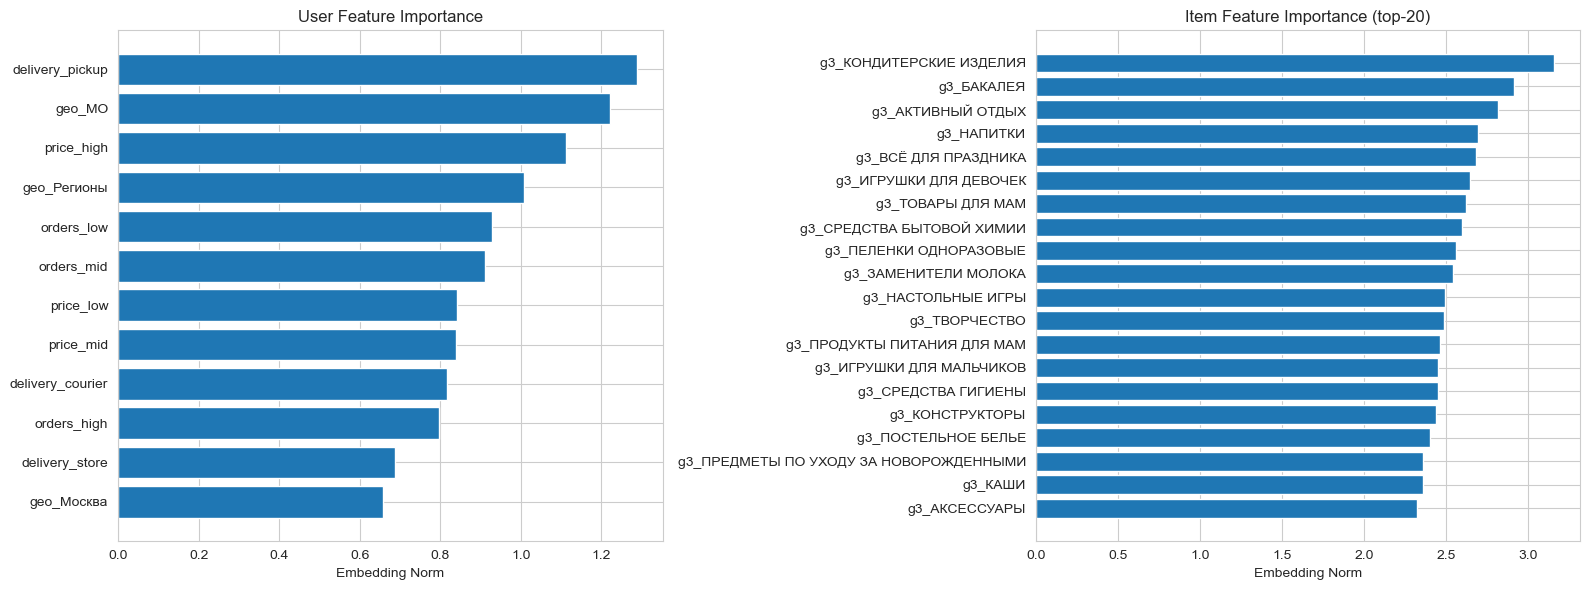

In [15]:
user_feat_norms = np.linalg.norm(model.user_embeddings[n_users:], axis=1)
user_feat_importance = pd.DataFrame({
    'feature': all_user_features,
    'norm': user_feat_norms
}).sort_values('norm', ascending=False)

item_feat_norms = np.linalg.norm(model.item_embeddings[n_items:], axis=1)
item_feat_importance = pd.DataFrame({
    'feature': all_item_features,
    'norm': item_feat_norms
}).sort_values('norm', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(user_feat_importance['feature'], user_feat_importance['norm'])
axes[0].set_xlabel('Embedding Norm')
axes[0].set_title('User Feature Importance')
axes[0].invert_yaxis()

top20 = item_feat_importance.head(20)
axes[1].barh(top20['feature'], top20['norm'])
axes[1].set_xlabel('Embedding Norm')
axes[1].set_title('Item Feature Importance (top-20)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()